# Data Exploration

### This notebook will contain the procedure followed for Data Exploration , Data Collection , Data Preprocessing . 

#### Initially we are using Flickr30K Dataset. WE are using a light weight dataset initially to completely set the pipeline for the model . 

##### A new benchmark collection for sentence-based image description and search, consisting of 30,000 images that are each paired with five different captions which provide clear descriptions of the salient entities and events. … The images were chosen from six different Flickr groups, and tend not to contain any well-known people or locations, but were manually selected to depict a variety of scenes and situations

In [9]:
# Importing all the Necessary Libraries
from pathlib import Path
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [1]:
# Importing Dataset using Kaggle 

data_dir = (Path.cwd().parent / "src" / "data").resolve()
data_dir.mkdir(parents=True, exist_ok=True)

path = kagglehub.dataset_download(
    "adityajn105/flickr30k",
    output_dir=str(data_dir)
)

print(path)

c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 8.16G/8.16G [42:37<00:00, 3.43MB/s]  


Extracting files...
C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\data


In [4]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR/"src"/"data"
IMAGES_DIR = DATA_DIR/"Images"
CAPTIONS_FILE = DATA_DIR/"captions.txt"

df = pd.read_csv(CAPTIONS_FILE)
df["image_path"] = df["image"].apply(lambda x: IMAGES_DIR/x)

print(df.shape)

df.head()

(158915, 3)


,image,caption,image_path
0,1000092795.jpg,Two young guys with shaggy hair look at their...,c:\Users\vishe\OneDrive\Desktop\VisionNarrator...
1,1000092795.jpg,"Two young , White males are outside near many...",c:\Users\vishe\OneDrive\Desktop\VisionNarrator...
2,1000092795.jpg,Two men in green shirts are standing in a yard .,c:\Users\vishe\OneDrive\Desktop\VisionNarrator...
3,1000092795.jpg,A man in a blue shirt standing in a garden .,c:\Users\vishe\OneDrive\Desktop\VisionNarrator...
4,1000092795.jpg,Two friends enjoy time spent together .,c:\Users\vishe\OneDrive\Desktop\VisionNarrator...


In [6]:
print("Unique Images : ", df["image"].nunique())

print("Total Captions : ", len(df))

Unique Images :  31783
Total Captions :  158915


#### The dataset Size clearly states that there are more than 30K images and more than 150K Captions . which is roughly 5 captions per image .

In [7]:
print("Missing image files : ", (~df["image_path"].apply(lambda p : p.exists())).sum())

Missing image files :  0


In [8]:
df.groupby("image").size().describe()

count    31783.0
mean         5.0
std          0.0
min          5.0
25%          5.0
50%          5.0
75%          5.0
max          5.0
dtype: float64

Thus the above description clerly shows that every image has exactly 5 caption . 

## Now lets visualize the images

In [10]:
def show_image_with_captions(image_name):
    rows = df[df["image"] == image_name]
    img = Image.open(rows.iloc[0]["image_path"])

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name)
    plt.show()

    for i, caption in enumerate(rows["caption"].tolist(), 1):
        print(f"{i}. {caption}")



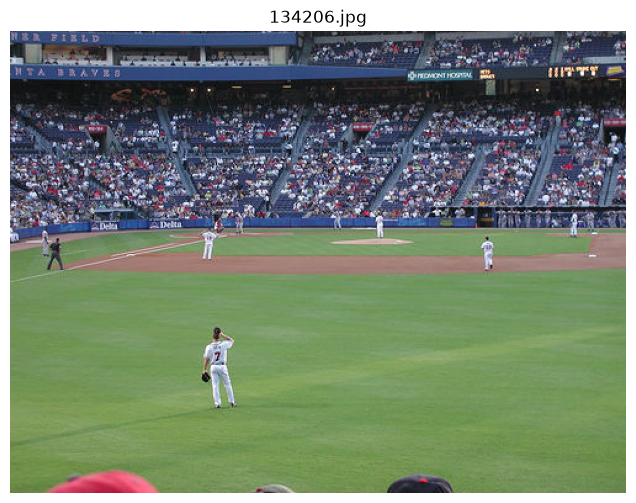

1.  The players of the baseball team are standing on the field , with many people watching from the stands .
2.  Baseball players are playing on a field in a stadium filled with people .
3.  A team plays baseball at a large crowded stadium .
4.  A crowd cheers on a baseball team .
5.  game is playing in the stadium


In [11]:
show_image_with_captions("134206.jpg")

#### Now lets, Randomly visualize the Dataset

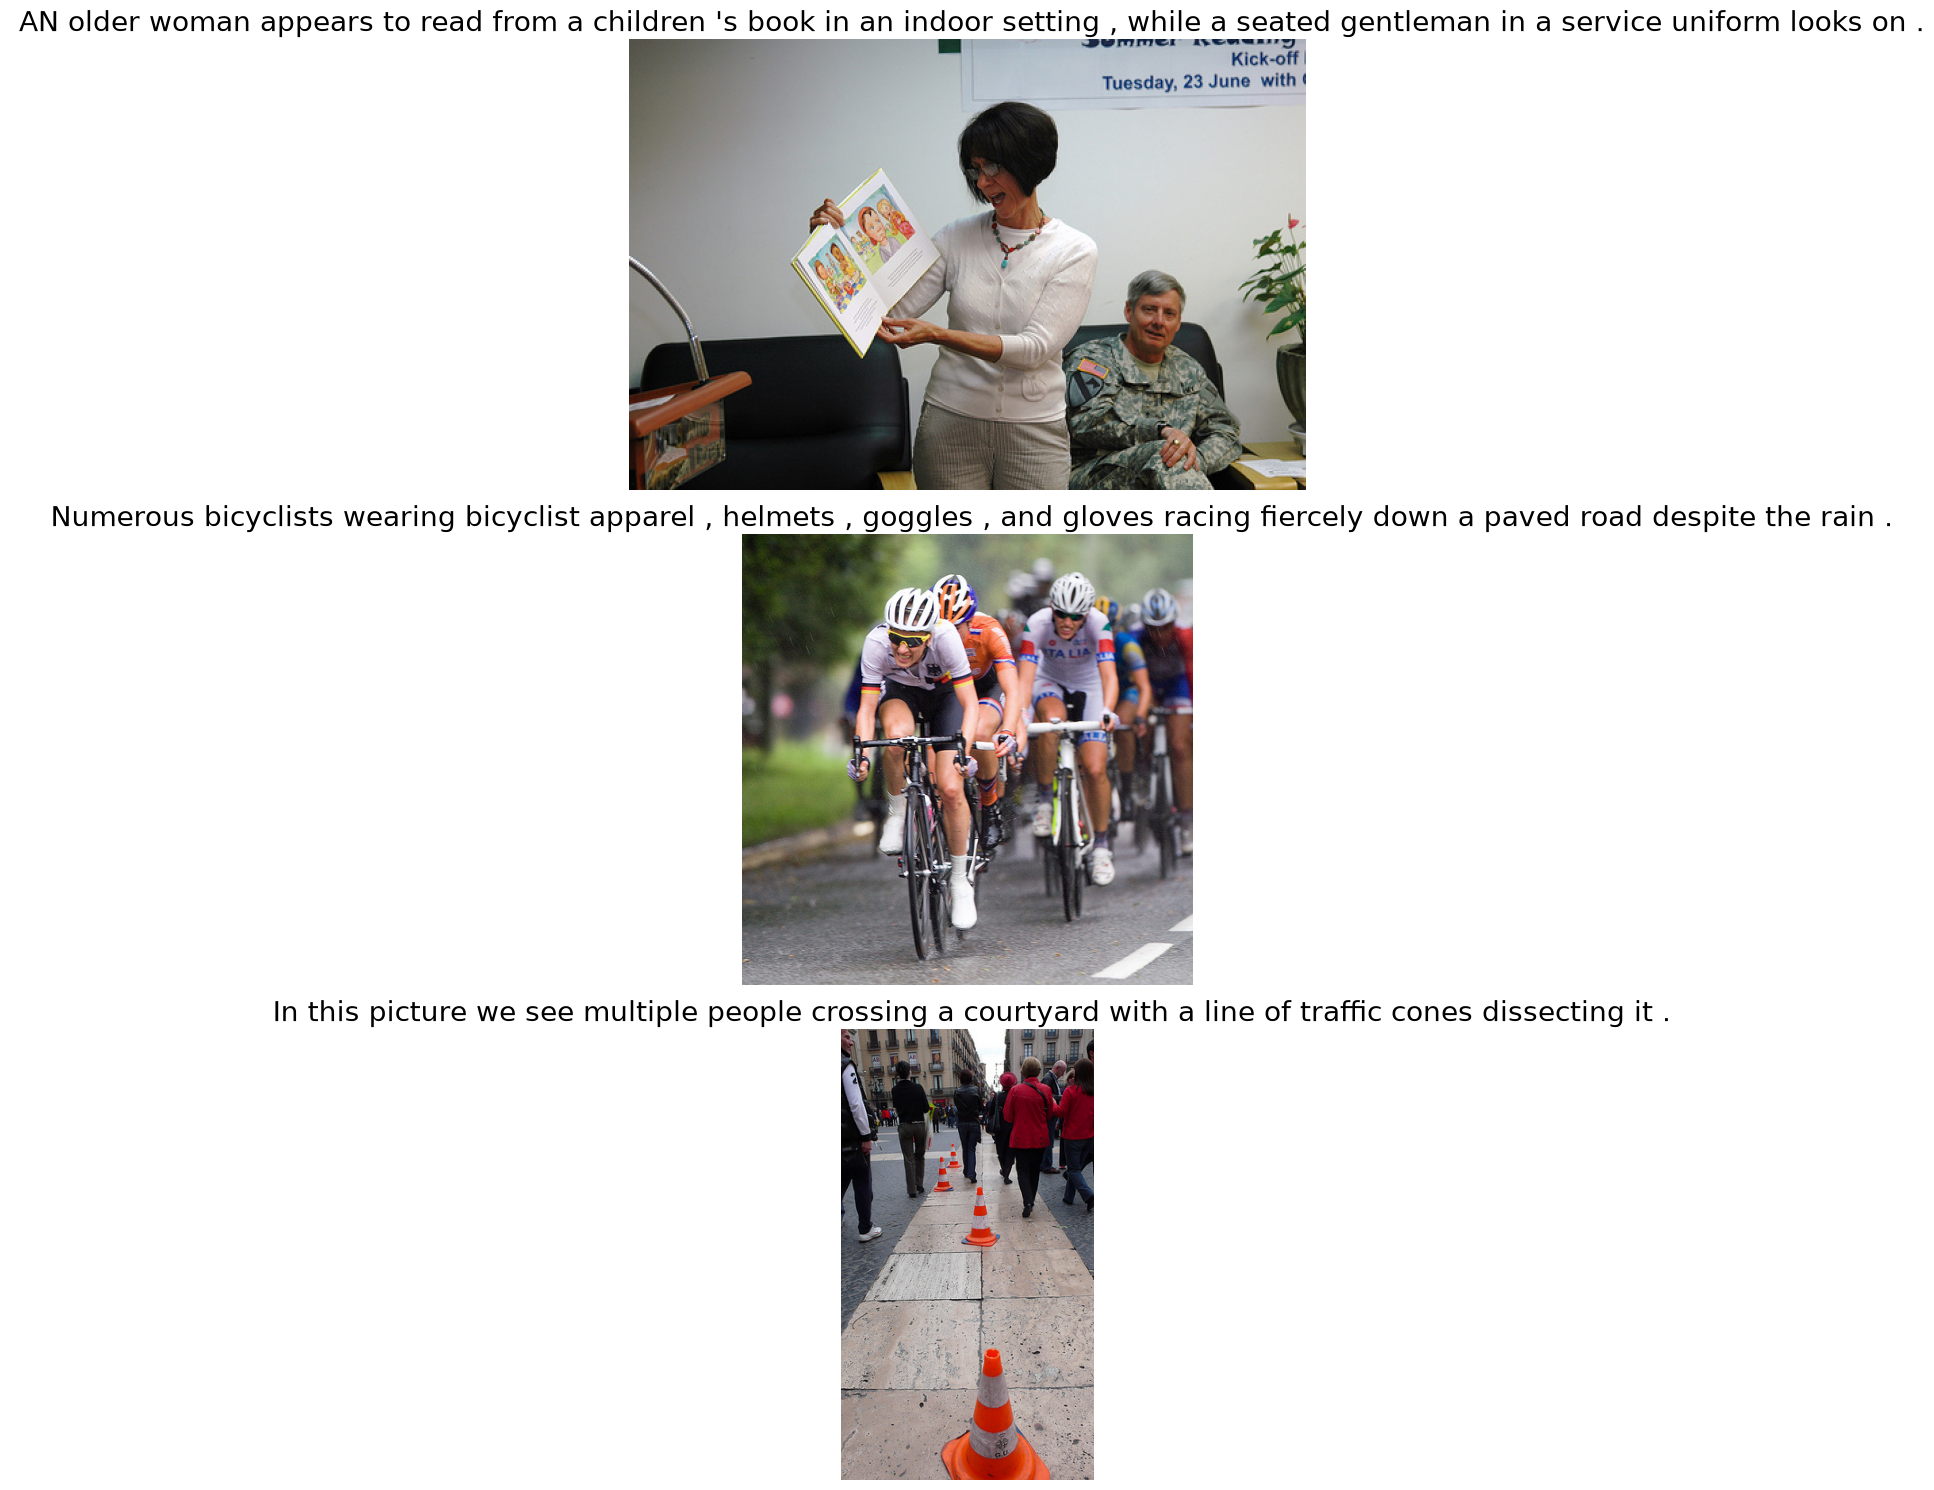

In [24]:
sample_images = df["image"].drop_duplicates().sample(6, random_state=42).tolist()

fig, axes = plt.subplots(3,1,figsize=(15,15))

axes = axes.flatten()

for ax, image_name in zip(axes, sample_images):
    img_path = IMAGES_DIR/ image_name
    img = Image.open(img_path)
    caption = df[df["image"] == image_name]["caption"].iloc[0]

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(caption, fontsize=20)

plt.tight_layout()
plt.show()

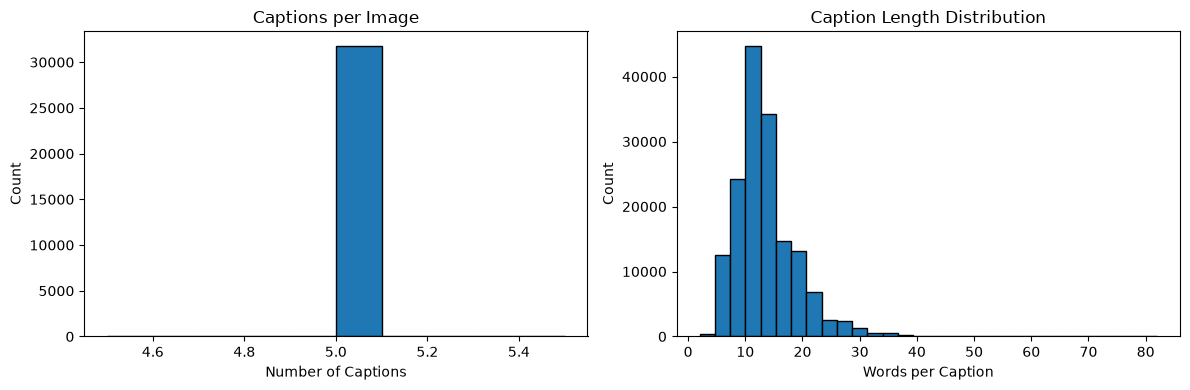

In [25]:
caption_counts = df.groupby("image").size()
caption_lengths = df["caption"].str.split().str.len()

fig, axes = plt.subplots(1,2, figsize=(12, 4))

axes[0].hist(caption_counts, bins=10, edgecolor="black")
axes[0].set_title("Captions per Image")
axes[0].set_xlabel("Number of Captions")
axes[0].set_ylabel("Count")

axes[1].hist(caption_lengths, bins=30, edgecolor="black")
axes[1].set_title("Caption Length Distribution")
axes[1].set_xlabel("Words per Caption")
axes[1].set_ylabel("Count")

plt.tight_layout()

plt.show()

So, On an average Most of the captions are in the range of (10, 30) words